# KNN & Logistic Regression

This notebook trains and evaluates two baseline classifiers for amphitheatre location prediction.

**Covered steps:**
1. Load train / val / test splits
2. Define feature sets (scaled for both models)
3. Train KNN - tune k with cross-validation
4. Train Logistic Regression - multinomial with class balancing
5. Evaluate both models on validation set
6. Compare and pick the best
7. Final evaluation on test set

## 1.Setup and Load Data 

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
import joblib
from pathlib import Path

DATA_DIR   = Path('../data/processed')
OUTPUT_DIR = Path('../models')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'train' / 'train_ready.csv')
val   = pd.read_csv(DATA_DIR / 'val' / 'val_ready.csv')
test  = pd.read_csv(DATA_DIR / 'test' / 'test_ready.csv')

for name, split in [('train', train), ('val', val), ('test', test)]:
    print(f"{name}: {split.shape}")

train: (4664, 40)
val: (999, 40)
test: (1000, 40)


## 2.Feature set

Both KNN and LR are distance-sensitive models and they require scaled features so we use _scaled columns and unscaled binary features

In [ ]:
TARGET = 'label_enc'

SCALED_FEATURES = [
    'accuracy_mean_scaled',
    'dist_Amphi_1_scaled', 'dist_Amphi_2_scaled', 'dist_Amphi_3_scaled',
    'dist_Amphi_4_scaled', 'dist_Amphi_5_scaled', 'dist_Amphi_6_scaled',
    'dist_Amphi_7_scaled', 'dist_Amphi_8_scaled',
    'dist_nearest_scaled', 'dist_2nd_scaled', 'dist_gap_scaled',
    'log_accuracy_scaled',
]

BINARY_FEATURES = [
    'is_outside',
    'high_accuracy_flag',
    'has_seat',
    'accuracy_bin',
    'seat_block_enc',
    'nearest_amphi_enc',
    'hour_sin',
    'hour_cos',
    'seat_row_filled',
    'seat_column_filled',
    'seat_zone_id',
]


FEATURES = SCALED_FEATURES + BINARY_FEATURES

X_train = train[FEATURES]
y_train = train[TARGET]

X_val   = val[FEATURES]
y_val   = val[TARGET]

X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Feature count : {len(FEATURES)}")
print(f"X_train shape : {X_train.shape}")
print(f"X_val   shape : {X_val.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"\nClasses: {sorted(y_train.unique())}")
print(f"\nClass distribution (train):")
print((y_train.value_counts().sort_index() / len(y_train) * 100).round(1).to_string())

Feature count : 20
X_train shape : (4664, 20)
X_val   shape : (999, 20)
X_test  shape : (1000, 20)

Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Class distribution (train):
label_enc
0     4.3
1    33.9
2     4.0
3    10.0
4    17.2
5    10.8
6     1.5
7    11.8
8     6.4


## 3.K-Nearest Neighbors

### 3.1 Tune k with cross-validation

We test odd values of k from 1 to 31 to avoid ties.  
We use **StratifiedKFold** to preserve class proportions in each fold.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_values  = list(range(1, 32, 2)) 
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    scores = cross_val_score(knn, X_train, y_train, cv=cv, scoring='f1_weighted')
    cv_scores.append(scores.mean())
    print(f"  k={k:2d}  →  F1-weighted = {scores.mean():.4f} ± {scores.std():.4f}")

best_k = k_values[np.argmax(cv_scores)]
print(f"\n Best k = {best_k}  (F1 = {max(cv_scores):.4f})")

  k= 1  →  F1-weighted = 0.9961 ± 0.0025
  k= 3  →  F1-weighted = 0.9929 ± 0.0016
  k= 5  →  F1-weighted = 0.9874 ± 0.0018
  k= 7  →  F1-weighted = 0.9776 ± 0.0026
  k= 9  →  F1-weighted = 0.9668 ± 0.0074
  k=11  →  F1-weighted = 0.9568 ± 0.0080
  k=13  →  F1-weighted = 0.9467 ± 0.0060
  k=15  →  F1-weighted = 0.9394 ± 0.0037
  k=17  →  F1-weighted = 0.9352 ± 0.0048
  k=19  →  F1-weighted = 0.9342 ± 0.0056
  k=21  →  F1-weighted = 0.9324 ± 0.0093
  k=23  →  F1-weighted = 0.9231 ± 0.0096
  k=25  →  F1-weighted = 0.9173 ± 0.0118
  k=27  →  F1-weighted = 0.9123 ± 0.0102
  k=29  →  F1-weighted = 0.9061 ± 0.0098
  k=31  →  F1-weighted = 0.9018 ± 0.0109

 Best k = 1  (F1 = 0.9961)


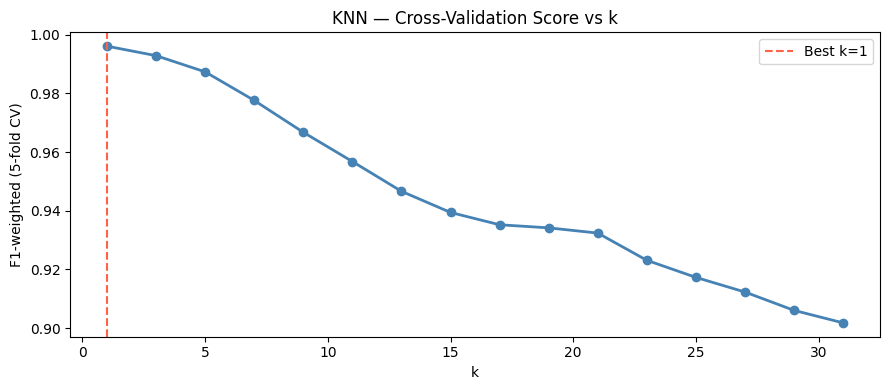

In [15]:
plt.figure(figsize=(9, 4))
plt.plot(k_values, cv_scores, marker='o', linewidth=2, color='steelblue')
plt.axvline(best_k, color='tomato', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k')
plt.ylabel('F1-weighted (5-fold CV)')
plt.title('KNN — Cross-Validation Score vs k')
plt.legend()
plt.tight_layout()
plt.show()

## 3.2 Train Final KNN

In [16]:
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='distance',  
    n_jobs=-1
)
knn_model.fit(X_train, y_train)

knn_val_preds = knn_model.predict(X_val)

knn_acc = accuracy_score(y_val, knn_val_preds)
knn_f1  = f1_score(y_val, knn_val_preds, average='weighted')

print(f"KNN Validation Results (k={best_k})")
print(f"  Accuracy  : {knn_acc:.4f}")
print(f"  F1-weighted: {knn_f1:.4f}")
print()
print(classification_report(y_val, knn_val_preds, zero_division=0))

KNN Validation Results (k=1)
  Accuracy  : 0.9990
  F1-weighted: 0.9990

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00       338
           2       1.00      1.00      1.00        41
           3       1.00      1.00      1.00       100
           4       1.00      1.00      1.00       172
           5       1.00      0.99      1.00       108
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00       117
           8       1.00      1.00      1.00        64

    accuracy                           1.00       999
   macro avg       1.00      1.00      1.00       999
weighted avg       1.00      1.00      1.00       999



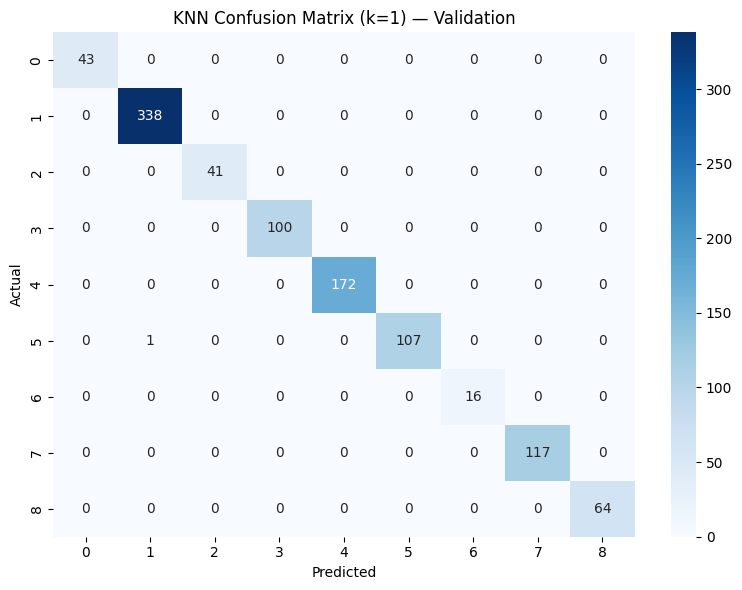

In [17]:
cm_knn = confusion_matrix(y_val, knn_val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title(f'KNN Confusion Matrix (k={best_k}) — Validation')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 4. Logistic Regression

We use **multinomial** logistic regression with:
- `class_weight='balanced'` → penalises misclassifying rare classes (label 6 = 1.5%) more heavily
- `max_iter=1000` → enough iterations for convergence on 9 classes
- `C` tuned via cross-validation (C = 1/λ, higher C = less regularisation)

In [ ]:
C_values  = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
lr_scores = []

for C in C_values:
    lr = LogisticRegression(
        C=C,
        solver='saga',
        class_weight='balanced',
        max_iter=10000,
        random_state=42
    )
    scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='f1_weighted')
    lr_scores.append(scores.mean())
    print(f"  C={C:5}  →  F1-weighted = {scores.mean():.4f} ± {scores.std():.4f}")

best_C = C_values[np.argmax(lr_scores)]
print(f"\n Best C = {best_C}  (F1 = {max(lr_scores):.4f})")

  C= 0.01  →  F1-weighted = 0.8461 ± 0.0042


## 4.2 Train Final Logistic Regression

In [19]:
lr_model = LogisticRegression(
    C=best_C,
    solver='saga',
    class_weight='balanced',
    max_iter=10000,
    random_state=42
)
lr_model.fit(X_train, y_train)

lr_val_preds = lr_model.predict(X_val)

lr_acc = accuracy_score(y_val, lr_val_preds)
lr_f1  = f1_score(y_val, lr_val_preds, average='weighted')

print(f"Logistic Regression Validation Results (C={best_C})")
print(f"  Accuracy   : {lr_acc:.4f}")
print(f"  F1-weighted: {lr_f1:.4f}")
print()
print(classification_report(y_val, lr_val_preds, zero_division=0))

Logistic Regression Validation Results (C=1.0)
  Accuracy   : 0.8869
  F1-weighted: 0.8909

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        43
           1       0.93      0.83      0.87       338
           2       0.76      0.93      0.84        41
           3       0.98      0.98      0.98       100
           4       0.97      0.97      0.97       172
           5       0.59      0.80      0.68       108
           6       0.89      1.00      0.94        16
           7       0.98      0.89      0.93       117
           8       0.97      0.97      0.97        64

    accuracy                           0.89       999
   macro avg       0.88      0.91      0.89       999
weighted avg       0.90      0.89      0.89       999



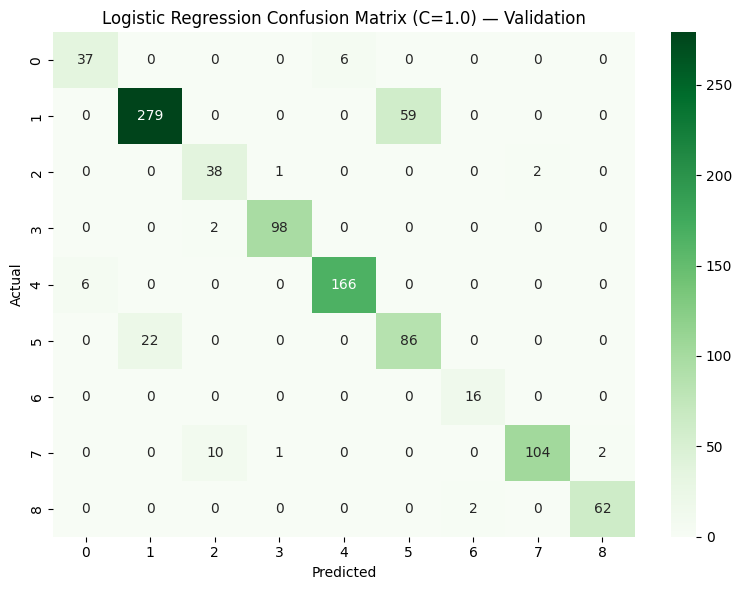

In [20]:
cm_lr = confusion_matrix(y_val, lr_val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title(f'Logistic Regression Confusion Matrix (C={best_C}) — Validation')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 5. Model Comparison

In [21]:
results = pd.DataFrame({
    'Model': ['KNN', 'Logistic Regression'],
    'Val Accuracy': [knn_acc, lr_acc],
    'Val F1-weighted': [knn_f1, lr_f1],
})
results = results.sort_values('Val F1-weighted', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

best_model_name = results.iloc[0]['Model']
best_model      = knn_model if best_model_name == 'KNN' else lr_model
print(f"\n Best model: {best_model_name}")

              Model  Val Accuracy  Val F1-weighted
                KNN      0.998999         0.998997
Logistic Regression      0.886887         0.890899

 Best model: KNN


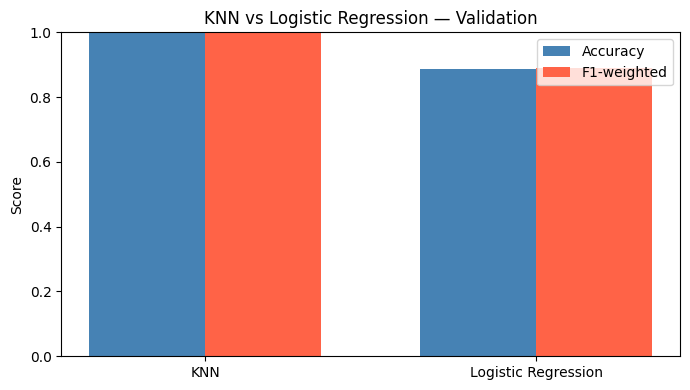

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, results['Val Accuracy'],    width, label='Accuracy',    color='steelblue')
ax.bar(x + width/2, results['Val F1-weighted'], width, label='F1-weighted', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('KNN vs Logistic Regression — Validation')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Final Evaluation on Test Set

In [23]:
test_preds = best_model.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)
test_f1  = f1_score(y_test, test_preds, average='weighted')

print(f"── {best_model_name} — TEST SET ───")
print(f"  Accuracy   : {test_acc:.4f}")
print(f"  F1-weighted: {test_f1:.4f}")
print()
print(classification_report(y_test, test_preds, zero_division=0))

── KNN — TEST SET ───
  Accuracy   : 0.9990
  F1-weighted: 0.9990

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00       339
           2       1.00      1.00      1.00        40
           3       1.00      0.99      0.99       100
           4       1.00      1.00      1.00       172
           5       1.00      1.00      1.00       109
           6       1.00      1.00      1.00        15
           7       0.99      1.00      1.00       118
           8       1.00      1.00      1.00        64

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



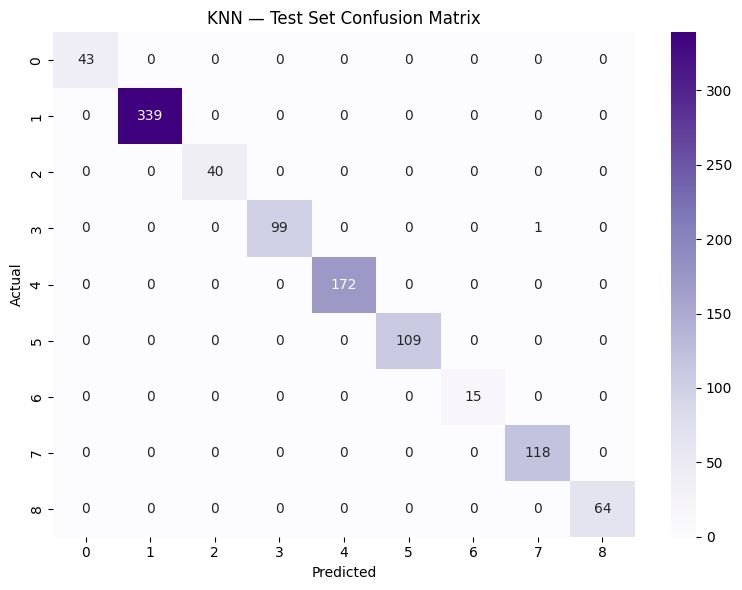

In [24]:
cm_test = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Purples')
plt.title(f'{best_model_name} — Test Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 7.Save Models

In [25]:
joblib.dump(knn_model, OUTPUT_DIR / 'knn_model.pkl')
joblib.dump(lr_model,  OUTPUT_DIR / 'lr_model.pkl')
print('Models saved to', OUTPUT_DIR)

Models saved to ..\models
